<a href="https://colab.research.google.com/github/VivekAChawla/AE-NI-Gradient-Library-Workflow/blob/main/CAVA_physics_informed_SCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! gdown --id 1gizuKTMdX_uZ3L6lsYTer51B42fgwHRo

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1gizuKTMdX_uZ3L6lsYTer51B42fgwHRo
From (redirected): https://drive.google.com/uc?id=1gizuKTMdX_uZ3L6lsYTer51B42fgwHRo&confirm=t&uuid=91dd0434-104c-4f43-9382-20b9c528c886
To: /content/SmBFOdata.npz
100% 2.30G/2.30G [00:28<00:00, 79.6MB/s]


In [ ]:
! pip install langchain
! pip install -U langchain-community
! pip install arxiv
! pip install openai
! pip install gcastle==1.0.4rc1
! pip install lingam
! pip install wget

In [ ]:
import os
from itertools import combinations
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from scipy import linalg
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pip install langchain-openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.1 MB/s eta 0:00:00


In [ ]:
!pip -q install -U langchain langchain-community langchain-openai duckduckgo-search


In [ ]:
# from langchain_openai import ChatOpenAI
# from langchain_community.tools import DuckDuckGoSearchRun
# from langchain.agents.react.agent import create_react_agent
# from langchain.agents import AgentExecutor
# from langchain.prompts import PromptTemplate


In [ ]:
!pip -q install -U gcastle lingam pydot
!apt-get -qq update
!apt-get -qq install -y graphviz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.4/134.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.9 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
from castle.common import GraphDAG
from castle.metrics import MetricsDAG
from castle.algorithms import PC
from castle.common.priori_knowledge import PrioriKnowledge

from lingam.utils import print_causal_directions, print_dagc, make_dot


In [ ]:
!pip -q install wget


  Preparing metadata (setup.py) ... done


In [ ]:
import networkx as nx
import numpy as np
import cv2
import h5py
import wget
import matplotlib.patches as pch
from sklearn import decomposition
from scipy import signal
import matplotlib.patches as patches
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from skimage import feature
import skimage
save_results = False
import matplotlib.colors as mcolors

# try:
#     import colorspacious
# except ModuleNotFoundError:
#     !pip install colorspacious
#     import colorspacious



In [ ]:
import torch
import random

# Setting seeds to reproduce the results
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic=True
np.random.seed(0)
random.seed(0)

In [ ]:
# your API key here

## Download SmBFO data

In [ ]:
os.makedirs("data", exist_ok = True)

In [ ]:
model_files = [
    'Sm_0_0_HAADF.h5','Sm_0_1_HAADF.h5','Sm_0_2_HAADF.h5',
    'Sm_0_0_UCParameterization.h5','Sm_0_1_UCParameterization.h5','Sm_0_2_UCParameterization.h5',
    'Sm_7_0_HAADF.h5','Sm_7_1_HAADF.h5','Sm_7_2_HAADF.h5','Sm_7_3_HAADF.h5','Sm_7_4_HAADF.h5',
    'Sm_7_0_UCParameterization.h5','Sm_7_1_UCParameterization.h5','Sm_7_2_UCParameterization.h5','Sm_7_3_UCParameterization.h5','Sm_7_4_UCParameterization.h5',
    'SM_10_0_HAADF.h5','Sm_10_1_HAADF.h5',
    'Sm_10_0_UCParameterization.h5','Sm_10_1_UCParameterization.h5',
    'Sm_13_0_HAADF.h5','Sm_13_1_HAADF.h5',
    'Sm_13_0_UCParameterization.h5','Sm_13_1_UCParameterization.h5',
    'Sm_20_0_HAADF.h5','Sm_20_1_HAADF.h5',
    'Sm_20_0_UCParameterization.h5','Sm_20_1_UCParameterization.h5'
]

base_url = "https://zenodo.org/record/4555979/files/"

for model_file in model_files:
    url = f"{base_url}{model_file}?download=1"
    output_path = os.path.join("data", model_file)
    print(f"Downloading {model_file}")
    wget.download(url, out=output_path)
    print()


## Data Preparation

In [ ]:
#list files
filedir = 'data'
[f for f in os.listdir(filedir)]

['Sm_13_1_HAADF.h5',
 'Sm_0_1_UCParameterization.h5',
 'Sm_20_1_HAADF.h5',
 'Sm_7_3_UCParameterization.h5',
 'Sm_7_4_HAADF.h5',
 'Sm_7_0_UCParameterization.h5',
 'Sm_10_1_HAADF.h5',
 'Sm_0_2_HAADF.h5',
 'Sm_13_0_HAADF.h5',
 'Sm_13_1_UCParameterization.h5',
 'Sm_20_0_HAADF.h5',
 'Sm_0_0_HAADF.h5',
 'Sm_7_0_HAADF.h5',
 'Sm_7_1_HAADF.h5',
 'Sm_7_4_UCParameterization.h5',
 'Sm_0_2_UCParameterization.h5',
 'Sm_10_1_UCParameterization.h5',
 'Sm_0_1_HAADF.h5',
 'Sm_20_1_UCParameterization.h5',
 'Sm_10_0_UCParameterization.h5',
 'Sm_7_2_HAADF.h5',
 'Sm_7_2_UCParameterization.h5',
 'Sm_20_0_UCParameterization.h5',
 'Sm_7_3_HAADF.h5',
 'Sm_7_1_UCParameterization.h5',
 'SM_10_0_HAADF.h5',
 'Sm_13_0_UCParameterization.h5',
 'Sm_0_0_UCParameterization.h5']

In [ ]:
#image files
composition_tags = [0,0,0,7,7,7,7,7,10,10,13,13,20,20]    #Sm composition %


img_filename = ['Sm_0_0_HAADF.h5','Sm_0_1_HAADF.h5','Sm_0_2_HAADF.h5',
                'Sm_7_0_HAADF.h5','Sm_7_1_HAADF.h5', 'Sm_7_2_HAADF.h5', 'Sm_7_3_HAADF.h5', 'Sm_7_4_HAADF.h5',
                'SM_10_0_HAADF.h5','Sm_10_1_HAADF.h5',
                'Sm_13_0_HAADF.h5','Sm_13_1_HAADF.h5',
                'Sm_20_0_HAADF.h5','Sm_20_1_HAADF.h5']

imnum = len(img_filename)

#paramterization files

UCparam_filename = ['Sm_0_0_UCParameterization.h5','Sm_0_1_UCParameterization.h5','Sm_0_2_UCParameterization.h5',
                    'Sm_7_0_UCParameterization.h5','Sm_7_1_UCParameterization.h5','Sm_7_2_UCParameterization.h5','Sm_7_3_UCParameterization.h5','Sm_7_4_UCParameterization.h5',
                    'Sm_10_0_UCParameterization.h5','Sm_10_1_UCParameterization.h5',
                    'Sm_13_0_UCParameterization.h5','Sm_13_1_UCParameterization.h5',
                    'Sm_20_0_UCParameterization.h5','Sm_20_1_UCParameterization.h5']

#load parameter files
UCparam = []
for x in UCparam_filename:
  print('loading parameterization file: ', os.path.join(filedir, x))
  temp = h5py.File(os.path.join(filedir, x), 'r')
  UCparam.append(temp)


#load images
imgdata = []
for x in img_filename:
  print('loading image file: ', os.path.join(filedir, x))
  temp = h5py.File(os.path.join(filedir, x), 'r')['MainImage']
  imgdata.append(temp)

print('UC parameterization:', [k for k in UCparam[0].keys()])

loading parameterization file:  data/Sm_0_0_UCParameterization.h5
loading parameterization file:  data/Sm_0_1_UCParameterization.h5
loading parameterization file:  data/Sm_0_2_UCParameterization.h5
loading parameterization file:  data/Sm_7_0_UCParameterization.h5
loading parameterization file:  data/Sm_7_1_UCParameterization.h5
loading parameterization file:  data/Sm_7_2_UCParameterization.h5
loading parameterization file:  data/Sm_7_3_UCParameterization.h5
loading parameterization file:  data/Sm_7_4_UCParameterization.h5
loading parameterization file:  data/Sm_10_0_UCParameterization.h5
loading parameterization file:  data/Sm_10_1_UCParameterization.h5
loading parameterization file:  data/Sm_13_0_UCParameterization.h5
loading parameterization file:  data/Sm_13_1_UCParameterization.h5
loading parameterization file:  data/Sm_20_0_UCParameterization.h5
loading parameterization file:  data/Sm_20_1_UCParameterization.h5
loading image file:  data/Sm_0_0_HAADF.h5
loading image file:  data/Sm

In [ ]:
#function maps x,y grid positions into a matrix data format
def map2grid(inab, inVal):

  default_val = np.nan
  abrng = [int(np.min(inab[:,0])), int(np.max(inab[:,0])), int(np.min(inab[:,1])), int(np.max(inab[:,1]))]
  abind = inab
  abind[:,0] -= abrng[0]
  abind[:,1] -= abrng[2]
  Valgrid = np.empty((abrng[1]-abrng[0]+1,abrng[3]-abrng[2]+1))
  Valgrid[:] = default_val
  Valgrid[abind[:,0].astype(int),abind[:,1].astype(int)]=inVal[:]
  return Valgrid, abrng

In [ ]:
SBFOdata = []                       #this will be the output list of dictionaries for each dataset
for i in np.arange(imnum):
  temp_dict = {'Index': i}
  temp_dict['Composition'] = composition_tags[i]
  temp_dict['Image'] = imgdata[i]
  temp_dict['Filename'] = img_filename[i]
  for k in UCparam[i].keys():       #add labels for UC parameterization
    temp_dict[k] = UCparam[i][k][()]

  #select values mapped to ab grid
  temp_dict['ab_a'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['ab'][()].T[:,0])[0]       #a array
  temp_dict['ab_b'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['ab'][()].T[:,1])[0]       #b array
  temp_dict['ab_x'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['xy_COM'][()].T[:,0])[0]   #x array
  temp_dict['ab_y'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['xy_COM'][()].T[:,1])[0]   #y array
  temp_dict['ab_Px'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['Pxy'][0])[0]             #Px array
  temp_dict['ab_Py'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['Pxy'][1])[0]             #Py array

  SBFOdata.append(temp_dict)

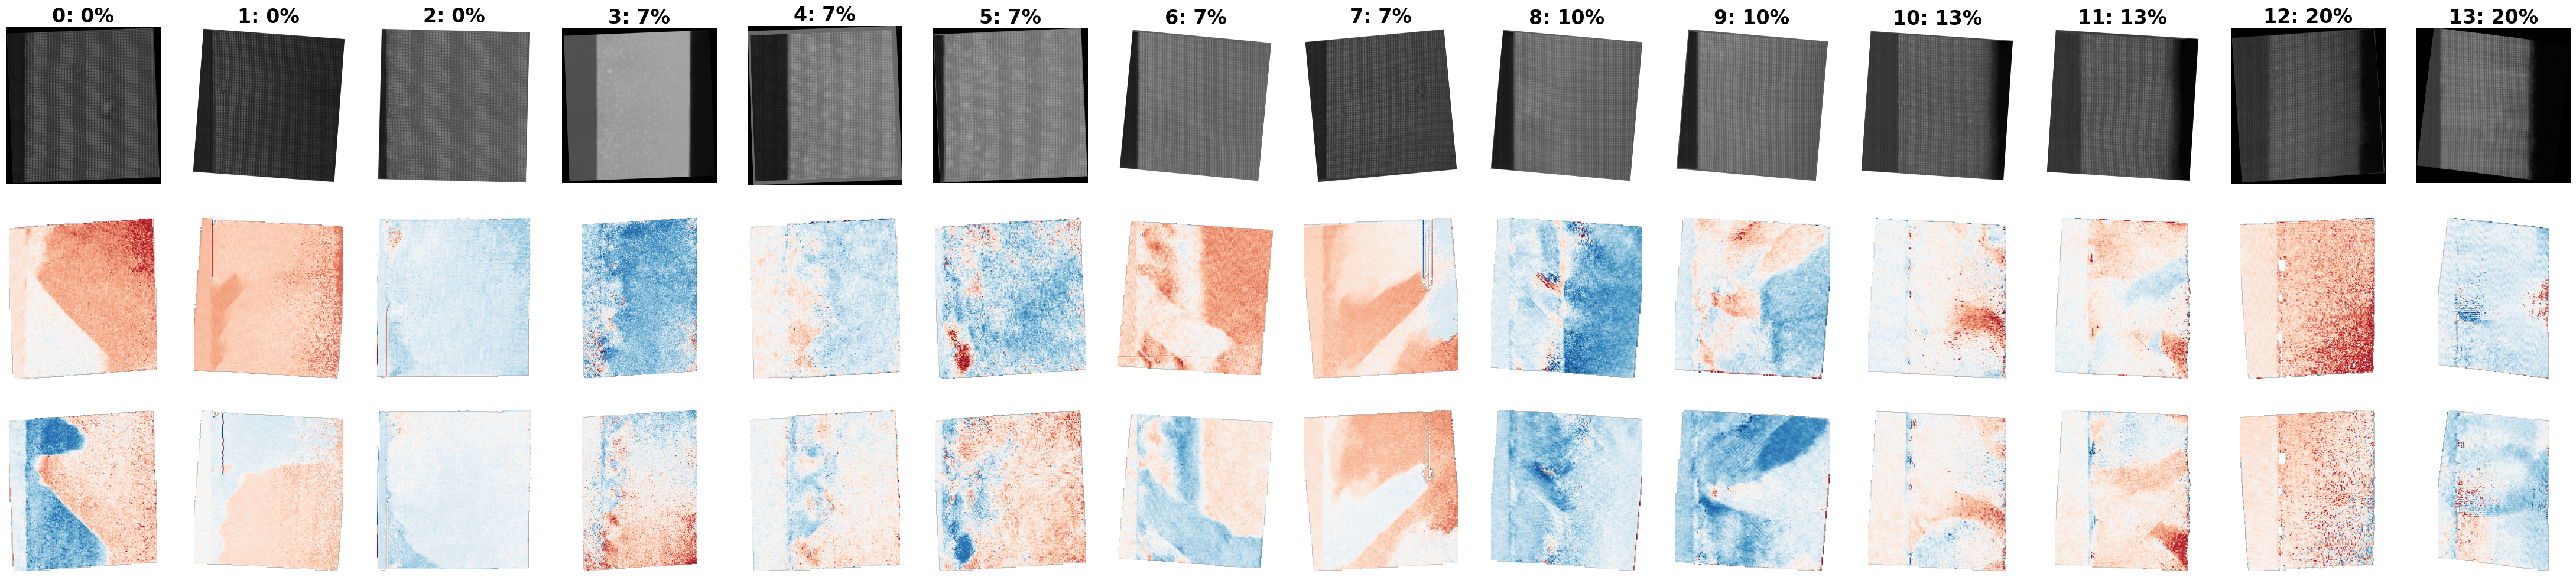

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=len(SBFOdata), figsize=(4*len(SBFOdata), 4*3), dpi=100)
for i, k in enumerate(SBFOdata):
  #Image
  ax[0,i].imshow(k['Image'], origin='upper', cmap='gray')
  ax[0,i].set_title(str(k['Index'])+': '+str(k['Composition'])+'%', fontsize = 24, fontweight = "bold")
  ax[0,i].set_axis_off()
  #Px
  ax[1,i].imshow(k['ab_Px'], origin='upper', cmap='RdBu')
  ax[1,i].set_axis_off()
  #Py
  ax[2,i].imshow(k['ab_Py'], origin='upper', cmap='RdBu')
  ax[2,i].set_axis_off()

## **Define parameters of interest**

In [ ]:
SmBFOdata = np.array(SBFOdata)
SmBFOdata = np.array([np.array(x) for x in SBFOdata])
SmBFOdata[0]

array({'Index': np.int64(0), 'Composition': 0, 'Image': <HDF5 dataset "MainImage": shape (4300, 4224), type "<f8">, 'Filename': 'Sm_0_0_HAADF.h5', 'I1': array([[181.013, 177.122, 181.539, ...,  42.298,  41.937,  41.137]]), 'I2': array([[ 6.492e-02,  4.846e+00,  1.402e+00, ..., -8.121e+01, -8.103e+01,
        -9.842e+00]]), 'I3': array([[ 0.77 ,  4.011, -1.023, ..., -0.335, -0.056,  9.842]]), 'I4': array([[-3.253e+00, -5.621e+00, -2.633e+00, ...,  3.347e-01,  5.589e-02,
        -1.028e+02]]), 'I5': array([[3.139, 3.153, 2.79 , ..., 0.827, 0.851,   inf]]), 'NCOM': array([[2699.292, 2673.792, 2672.988, ..., 1806.132, 3005.532,  121.605],
       [3097.785, 3097.867, 3071.336, ...,   97.279,  147.109, 1614.218]]), 'PCOM': array([[2697.373, 2671.237, 2670.42 , ..., 1806.56 , 3006.035,  122.168],
       [3095.592, 3095.571, 3069.046, ...,   99.503,  149.34 , 1612.91 ]]), 'Pxy': array([[-1.919, -2.554, -2.568, ...,  0.428,  0.504,  0.563],
       [-2.194, -2.296, -2.29 , ...,  2.225,  2.231, -

In [ ]:
def convert_entry(entry):
    entry = entry.item()          # 🔑 unwrap 0-d numpy object
    entry = dict(entry)           # copy dict
    if "Image" in entry:
        entry["Image"] = entry["Image"][:]   # HDF5 → NumPy
    return entry

SmBFOdata_clean = np.array(
    [convert_entry(e) for e in SmBFOdata],
    dtype=object
)




In [ ]:
np.savez("SmBFOdata.npz", SmBFOdata=SmBFOdata_clean)

In [ ]:
data = np.load("SmBFOdata.npz", allow_pickle=True)
SmBFOdata = data["SmBFOdata"]

In [ ]:
SmBFOdata

array([{'Index': np.int64(0), 'Composition': 0, 'Image': array([[0., 0., 0., ..., 0., 0., 0.],
              [0., 0., 0., ..., 0., 0., 0.],
              [0., 0., 0., ..., 0., 0., 0.],
              ...,
              [0., 0., 0., ..., 0., 0., 0.],
              [0., 0., 0., ..., 0., 0., 0.],
              [0., 0., 0., ..., 0., 0., 0.]]), 'Filename': 'Sm_0_0_HAADF.h5', 'I1': array([[181.013, 177.122, 181.539, ...,  42.298,  41.937,  41.137]]), 'I2': array([[ 6.492e-02,  4.846e+00,  1.402e+00, ..., -8.121e+01, -8.103e+01,
               -9.842e+00]]), 'I3': array([[ 0.77 ,  4.011, -1.023, ..., -0.335, -0.056,  9.842]]), 'I4': array([[-3.253e+00, -5.621e+00, -2.633e+00, ...,  3.347e-01,  5.589e-02,
               -1.028e+02]]), 'I5': array([[3.139, 3.153, 2.79 , ..., 0.827, 0.851,   inf]]), 'NCOM': array([[2699.292, 2673.792, 2672.988, ..., 1806.132, 3005.532,  121.605],
              [3097.785, 3097.867, 3071.336, ...,   97.279,  147.109, 1614.218]]), 'PCOM': array([[2697.373, 2671.237,

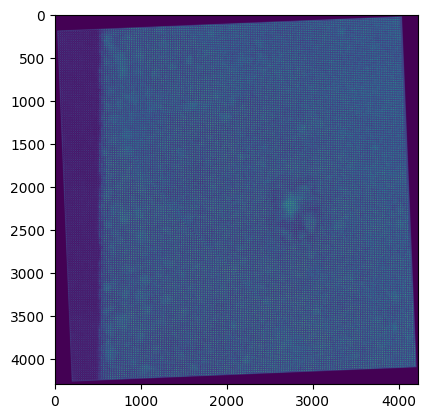

In [ ]:
plt.imshow(SmBFOdata[0]["Image"])

In [ ]:
file_path = "SmBFOdata.npz"
size_bytes = os.path.getsize(file_path)

print(f"Size: {size_bytes / (1024**2):.2f} MB")

Size: 2193.52 MB


In [ ]:
for entry in SBFOdata:  # Assuming `your_array` is the name of your data
    print(entry.keys())

dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'adelta', 'alpha', 'atmindex', 'b', 'bdelta', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms', 'ab_a', 'ab_b', 'ab_x', 'ab_y', 'ab_Px', 'ab_Py'])
dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'abdelta', 'alpha', 'atmindex', 'b', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms', 'ab_a', 'ab_b', 'ab_x', 'ab_y', 'ab_Px', 'ab_Py'])
dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'abdelta', 'alpha', 'atmindex', 'b', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms', 'ab_a', 'ab_b', 'ab_x', 'ab_y', 'ab_Px', 'ab_Py'])
dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'adelta', 'alpha', 'atmindex', 'b', 

In [ ]:
# # Function to extract mean values from arrays in SBFOdata
def extract_mean_values(entry):
     return {
        'Alkali_Cations': np.nanmean(entry['I1']),
        'Transition_Metal_Cations': np.nanmean(entry['I5']),
        'Lattice_Parameter': np.nanmean(entry['a']),
        'Composition': np.nanmean(entry['Composition']),
        'Unit_Cell_Angle': np.nanmean(entry['alpha']),
        'Volume': np.nanmean(entry['Vol']),
        'In_Plane_Polarization': np.nanmean(entry['Pxy'][0]),  # Assuming Px is the first component of Pxy
#         'Py': np.nanmean(entry['Pxy'][1])   # Assuming Py is the second component of Pxy
    }

# Extract relevant data and handle NaNs and inf values
data_entries = []
for entry in SBFOdata:
    data_entries.append(extract_mean_values(entry))

# Convert to DataFrame
df = pd.DataFrame(data_entries).replace([np.inf, -np.inf], np.nan).dropna()

# Ensure no extremely large values
max_value = np.finfo(np.float64).max
df = df.clip(upper=max_value)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
print(SmBFOdata.dtype)
print(SmBFOdata.shape)
print(SmBFOdata[0].keys())

object
(14,)
dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'adelta', 'alpha', 'atmindex', 'b', 'bdelta', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms', 'ab_a', 'ab_b', 'ab_x', 'ab_y', 'ab_Px', 'ab_Py'])


In [ ]:
def extract_physical_values(entry):
    return {
        'Alkali_Cations': entry['I1'].flatten(),
        'Transition_Metal_Cations': entry['I5'].flatten(),
        'Lattice_Parameter': entry['a'].flatten(),
        'Composition': entry['Composition'],  # No flattening needed
        'Unit_Cell_Angle': entry['alpha'].flatten(),
        'Volume': entry['Vol'].flatten(),
        'In_Plane_Polarization': entry['Pxy'][0].flatten(),
    }

data_entries = []
for entry in SBFOdata:
    extracted = extract_physical_values(entry)
    for i in range(len(extracted['Alkali_Cations'])):
        data_entries.append({
            'Alkali_Cations': extracted['Alkali_Cations'][i],
            'Transition_Metal_Cations': extracted['Transition_Metal_Cations'][i],
            'Lattice_Parameter': extracted['Lattice_Parameter'][i],
            'Composition': extracted['Composition'],
            'Unit_Cell_Angle': extracted['Unit_Cell_Angle'][i],
            'Volume': extracted['Volume'][i],
            'In_Plane_Polarization': extracted['In_Plane_Polarization'][i],
            # 'In_Plane_Polarization_Y': extracted['In_Plane_Polarization_Y'][i]
        })

# Convert to DataFrame
df = pd.DataFrame(data_entries).replace([np.inf, -np.inf], np.nan).dropna()

# Ensure no extremely large values
max_value = np.finfo(np.float64).max
df = df.clip(upper=max_value)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


In [ ]:
all_vars = {
    'Alkali_Cations': 0,
    'Transition_Metal_Cations': 1,
    'Lattice_Parameter': 2,
    'Composition': 3,  # Placeholder for the missing index
    'Unit_Cell_Angle': 4,
    'Volume': 5,
    'In_Plane_Polarization': 6
}

In [ ]:
# Create the inverse mapping from indices to variable names
inverse_var_map = {v: k for k, v in all_vars.items()}

In [ ]:
e = SmBFOdata[0]  # or SBFOdata[0]
for k in ["I1","I5","a","b","ab","Vol","alpha","Pxy"]:
    v = np.asarray(e[k])
    print(k, v.shape, v.size)


I1 (1, 23815) 23815
I5 (1, 23815) 23815
a (2, 23815) 47630
b (2, 23815) 47630
ab (2, 23815) 47630
Vol (1, 23815) 23815
alpha (1, 23815) 23815
Pxy (2, 23815) 47630


## **PC discovery without LLM assist**
**gcastle**

In [ ]:
# PC discovery without LLM assist
pc = PC(variant='stable')
pc.learn(scaled_data)

# Create the inverse mapping from indices to variable names
inverse_var_map = {v: k for k, v in all_vars.items()}

# Replace the indices with variable names in the DAG matrix
labels = [inverse_var_map[i] for i in range(pc.causal_matrix.shape[0])]
pc_dag_named = pd.DataFrame(pc.causal_matrix, index=labels, columns=labels)

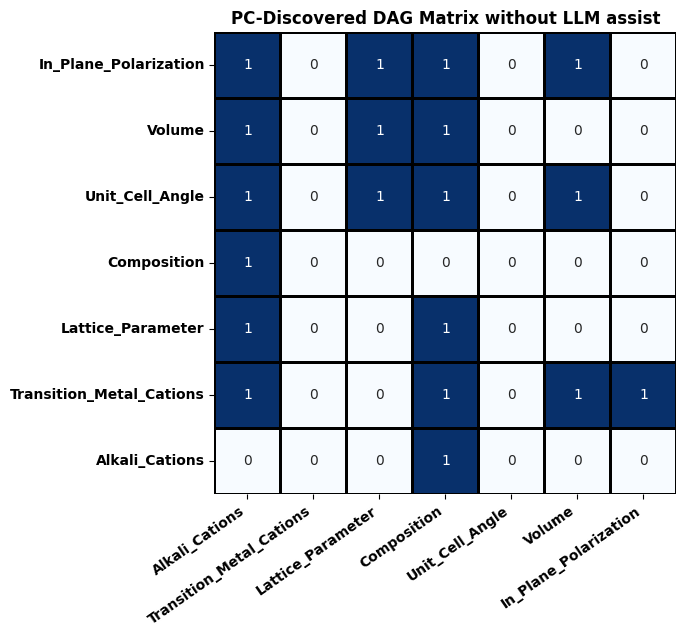

In [ ]:
# Plot the DAG matrix with names using seaborn heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(pc_dag_named, annot=True, cmap='Blues', cbar=False, square=True, linewidths=.8, linecolor='black')
plt.title('PC-Discovered DAG Matrix without LLM assist', fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

# Invert the y-axis
plt.gca().invert_yaxis()
plt.show()

Real names

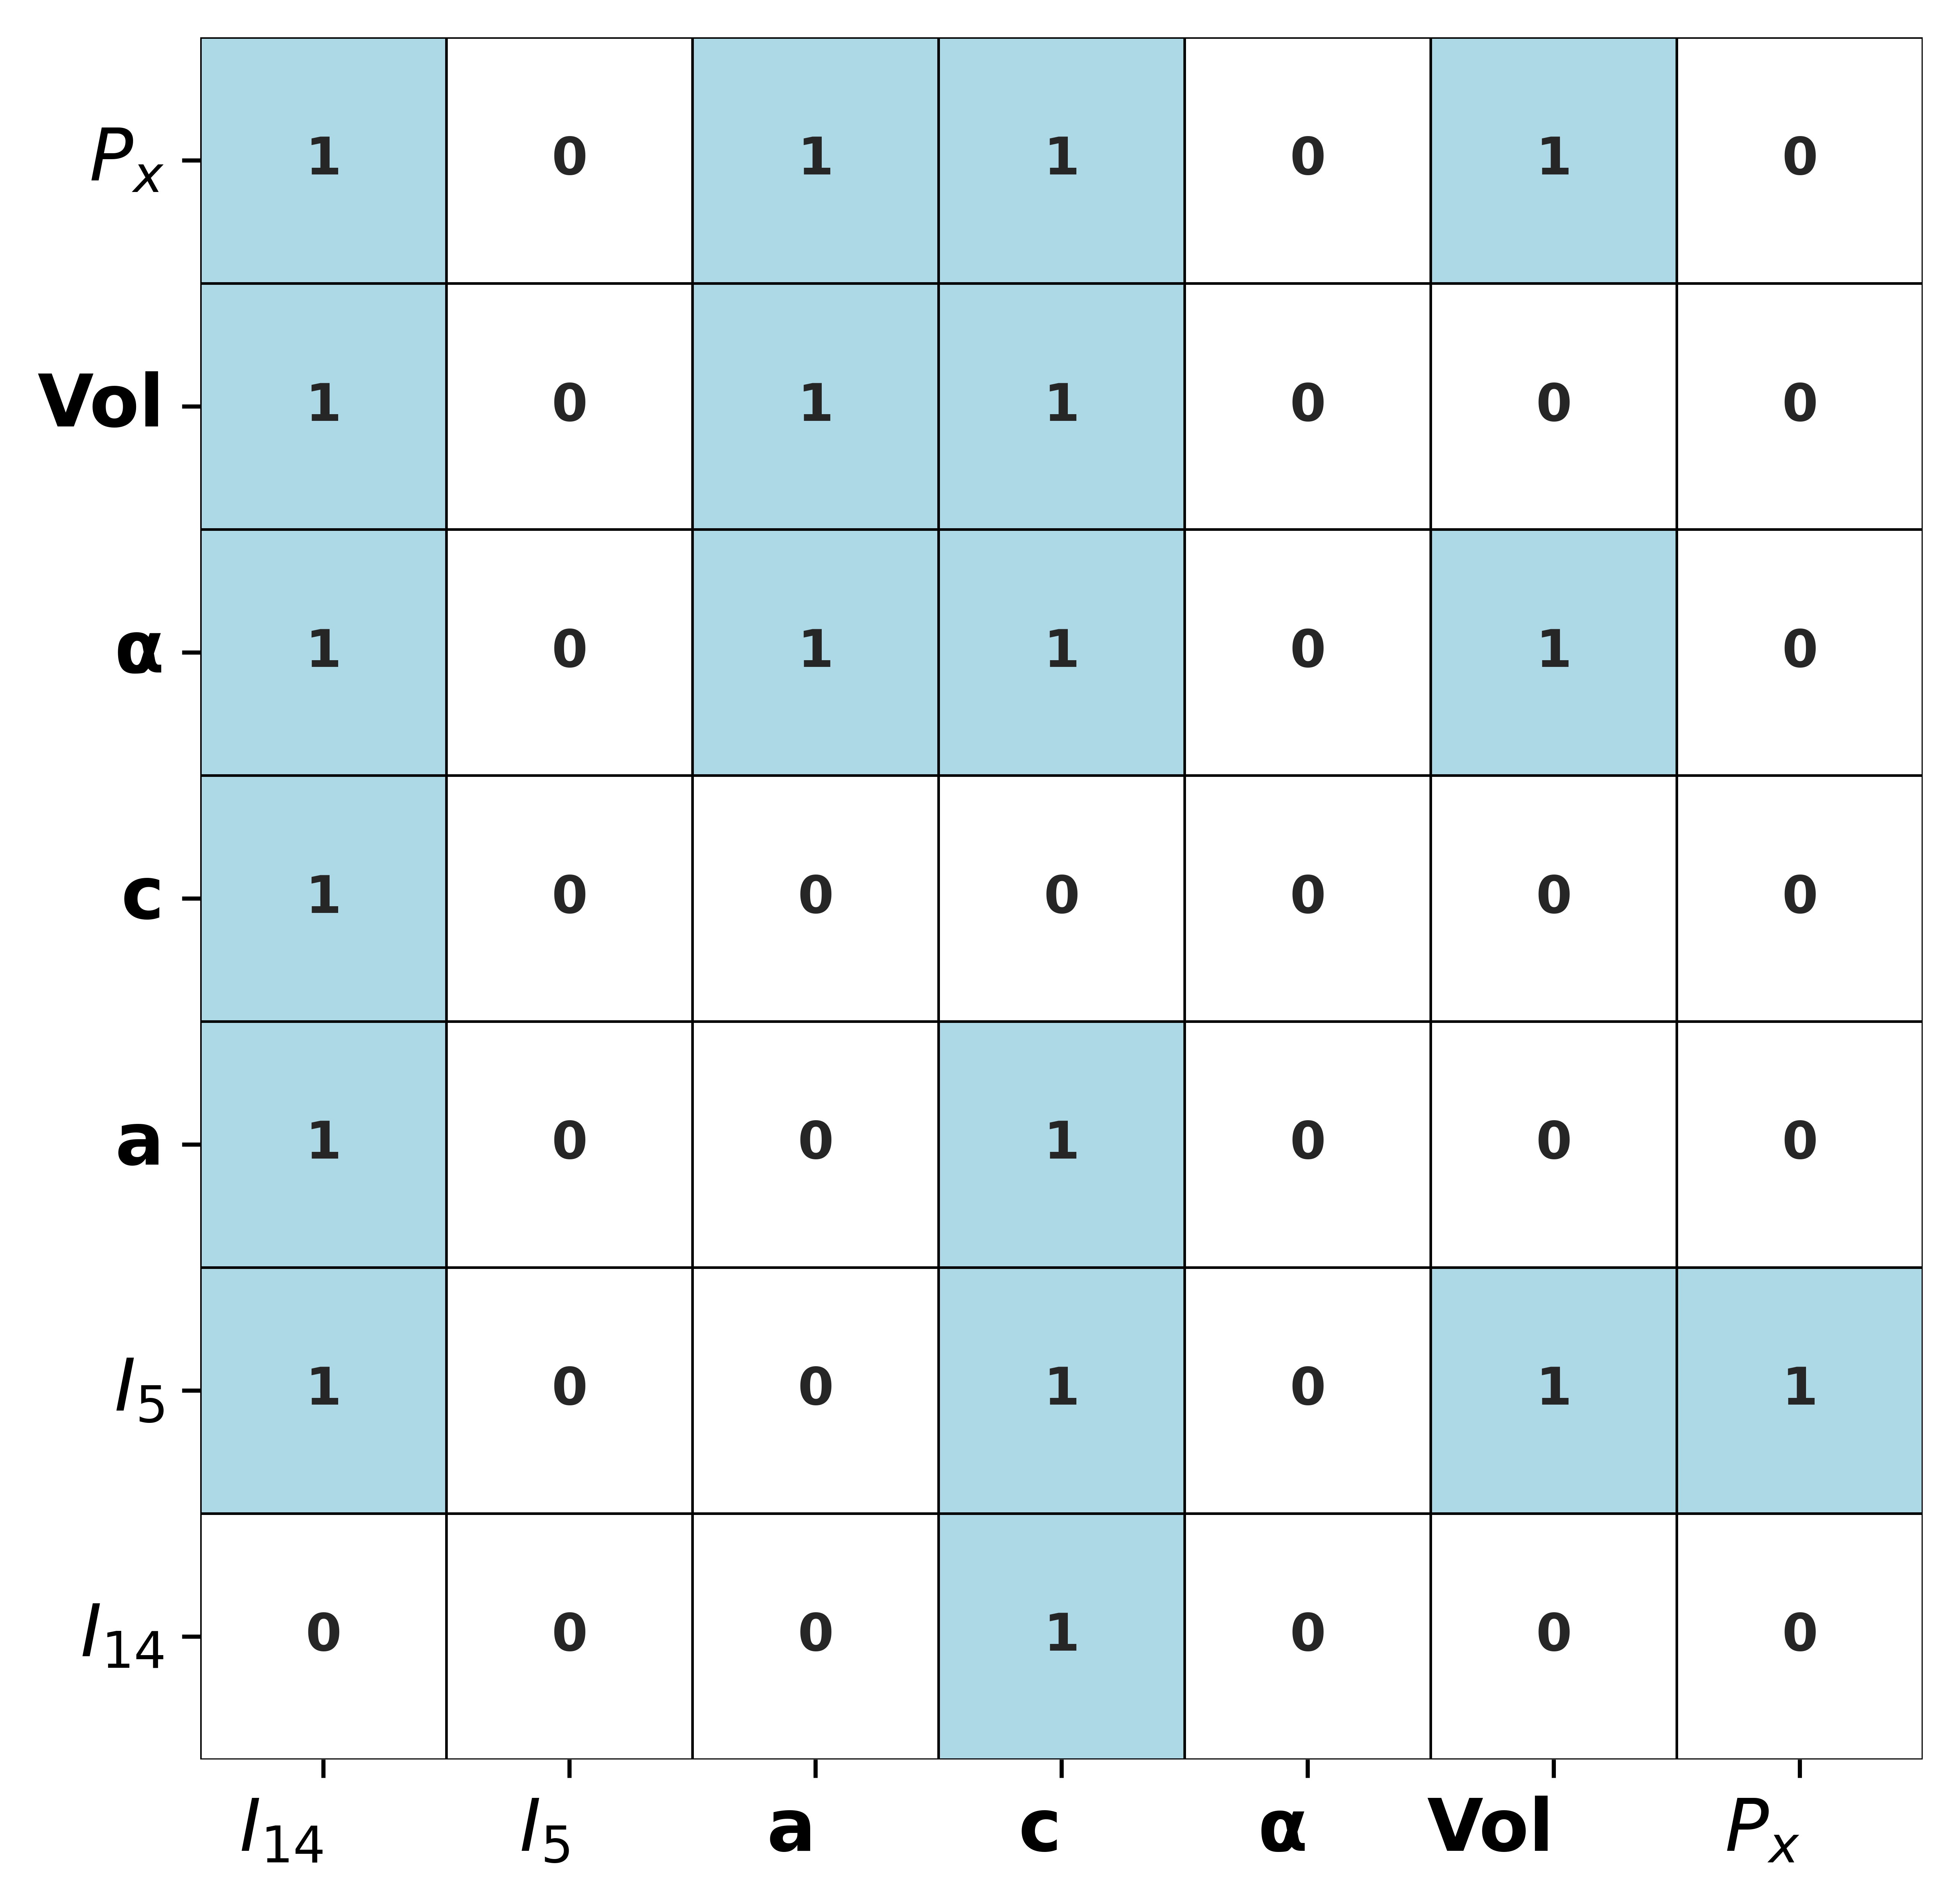

In [ ]:
# Define the updated variable names (real values)
all_vars_real = {
    '$I_{14}$': 0,
    '$I_5$': 1,
    'a': 2,
    'c': 3,
    'α': 4,
    'Vol': 5,
    '$P_x$': 6
}

# Create the inverse mapping for real variable names
inverse_var_map_real = {v: k for k, v in all_vars_real.items()}

# Example DAG matrix (Replace this with your real data)
pc_dag_real = np.array([
    [0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 1, 0, 1, 1],
    [1, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 0, 1, 0],
    [1, 0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 1, 0]
])

# Plot the DAG matrix with real names using seaborn heatmap
plt.figure(figsize=(6, 6), dpi = 1000)
sns.heatmap(
    pc_dag_real,
    annot=True,
    cmap=sns.color_palette(["white", "lightblue"]),  # Custom color for 1 values
    cbar=False,  # No color bar since it's binary
    square=True,
    xticklabels=inverse_var_map_real.values(),
    yticklabels=inverse_var_map_real.values(),
    linewidths=.5,
    linecolor='black',
    annot_kws={"size": 10, "weight": "bold"},
    fmt='d'
)
# plt.title('PC-Discovered DAG', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, ha='right', fontsize=14, fontweight='bold')
plt.yticks(rotation=0, fontsize=14, fontweight='bold')

# Invert the y-axis
plt.gca().invert_yaxis()

plt.show()

# Building The Data 10D

## Keep in mind length of SmBFO is 14 we are compiling into one

Checking the structure

In [ ]:
e = SmBFOdata[3]  # or SBFOdata[0]
for k in ["I1","I5","a","b","ab","Vol","alpha","Pxy"]:
    v = np.asarray(e[k])
    print(k, v.shape, v.size)


I1 (1, 64932) 64932
I5 (1, 64932) 64932
a (2, 64932) 129864
b (2, 64932) 129864
ab (2, 64932) 129864
Vol (1, 64932) 64932
alpha (1, 64932) 64932
Pxy (2, 64932) 129864


a,  b are not aligned the same

In [ ]:
np.asarray(np.asarray(e["a"][:,1]))

array([26.495,  0.351])

In [ ]:
np.asarray(np.asarray(e["b"][:,10000]))

array([ 0.879, 26.545])

In [ ]:
np.asarray(np.asarray(e["ab"][:,10000]))

array([-58., 109.])

In [ ]:
np.asarray(np.asarray(e["Pxy"][:,10000]))

array([-3.483, -2.218])

In [ ]:
len(SmBFOdata)


14

In [ ]:
import numpy as np
import pandas as pd

data_list = SmBFOdata  # or SBFOdata

def extract_10vars_custom(entry, a_idx=0, b_idx=1, ab_idx=1):
    # number of sites
    n = np.asarray(entry["I1"]).shape[-1]

    # (1, n) -> (n,)
    I1 = np.asarray(entry["I1"]).reshape(-1)
    I2 = np.asarray(entry["I2"]).reshape(-1)
    I3 = np.asarray(entry["I3"]).reshape(-1)
    I4 = np.asarray(entry["I4"]).reshape(-1)
    I5 = np.asarray(entry["I5"]).reshape(-1)

    Vol   = np.asarray(entry["Vol"]).reshape(-1)
    alpha = np.asarray(entry["alpha"]).reshape(-1)

    # derived I14
    I14 = I1 + I2 + I3 + I4

    # (2, n): choose correct component per your observation
    a2  = np.asarray(entry["a"])
    b2  = np.asarray(entry["b"])
    ab2 = np.asarray(entry["ab"])

    a  = a2[a_idx, :]
    b  = b2[b_idx, :]
    ab = ab2[ab_idx, :]

    # Pxy (2, n): Px and Py
    Pxy = np.asarray(entry["Pxy"])
    px = Pxy[0, :]
    py = Pxy[1, :]
    pxy = np.sqrt(px**2 + py**2)

    # sanity checks
    arrays = [I14, I5, a, b, ab, Vol, alpha, px, py, pxy]
    names  = ["I14","I5","a","b","ab","Vol","alpha","px","py","pxy"]
    for nm, arr in zip(names, arrays):
        if len(arr) != n:
            raise ValueError(f"{nm} length mismatch: {len(arr)} vs {n}")

    return {
        "I14": I14,
        "I5": I5,
        "a": a,
        "b": b,
        "ab": ab,
        "Vol": Vol,
        "alpha": alpha,
        "px": px,
        "py": py,
        "pxy": pxy,
    }

# Build df10
rows = []
for entry in data_list:
    out = extract_10vars_custom(entry, a_idx=0, b_idx=1, ab_idx=1)
    n = len(out["I14"])
    for i in range(n):
        rows.append({k: float(out[k][i]) for k in out.keys()})

df10 = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()

print("df10 shape:", df10.shape)
print(df10.head())


df10 shape: (355207, 10)
          I14        I5          a          b     ab         Vol      alpha  \
0  178.594151  3.138715  26.124127  26.489840  115.0  691.512926  86.837358   
1  180.358146  3.152780  26.147211  26.594204  115.0  695.850669  89.316177   
2  179.284168  2.789736  25.897452  26.456106  114.0  685.455251  89.274180   
3  182.021102  3.189277  26.298236  26.561052  114.0  698.125675  87.185390   
4  193.836166  2.602658  26.439611  26.841898  125.0  709.686703  88.588781   

         px        py       pxy  
0 -1.918706 -2.193673  2.914385  
1 -2.554426 -2.296190  3.434761  
2 -2.567754 -2.289612  3.440303  
3 -2.371505 -1.827032  2.993674  
4 -1.829295 -2.245027  2.895940  


# Physics informed SCM

X shape: (355207, 10)
I14 <- [] score 1.05
I5 <- [] score 1.05
a <- ['I14'] score 1.0058
b <- ['I14'] score 1.0159
ab <- ['I14', 'a'] score 0.9388
alpha <- ['a'] score 1.0435
Vol <- ['b'] score 0.0575
px <- ['ab'] score 0.9937
py <- ['ab'] score 1.0098
pxy <- ['py'] score 0.8412

Adjacency matrix:
 [[0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]]


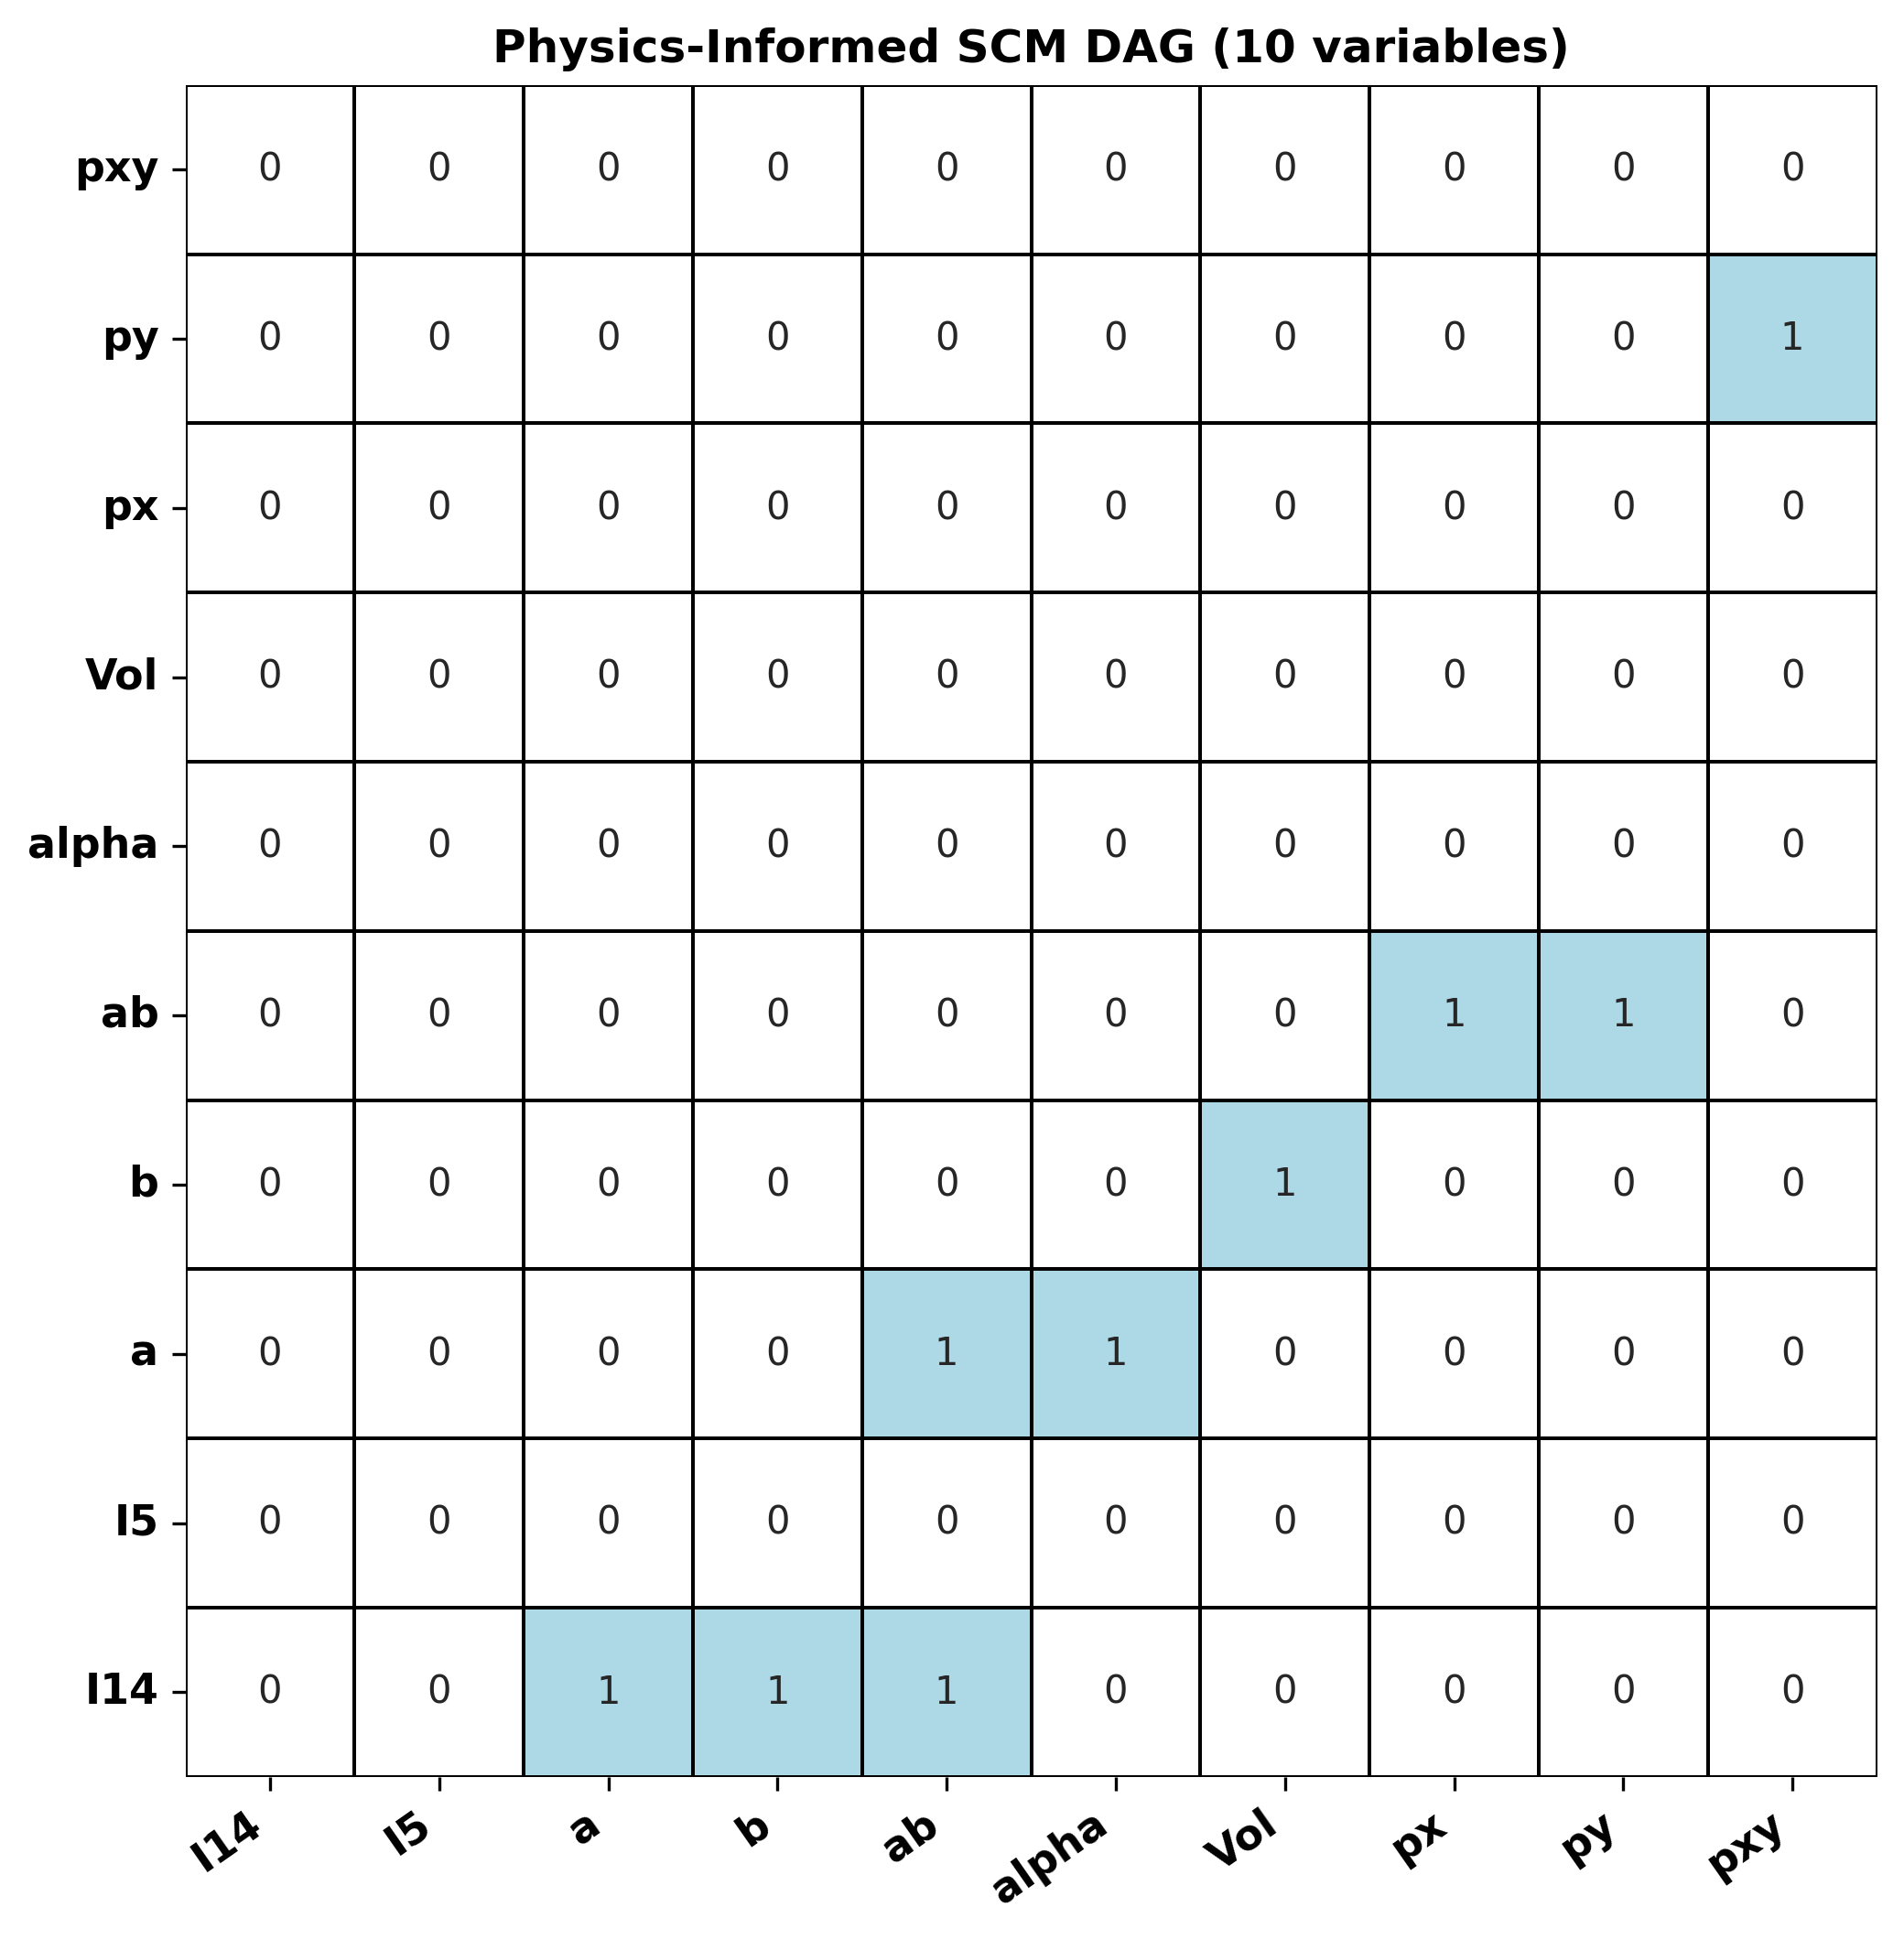

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# --------------------------------------------------
# 1) Canonicalize df10 columns (assumes df10 already exists)
# --------------------------------------------------
df2 = df10.copy()

# Ensure required columns exist
names = ["I14","I5","a","b","ab","alpha","Vol","px","py","pxy"]
missing = [c for c in names if c not in df2.columns]
if missing:
    raise ValueError(f"Missing columns in df10: {missing}\nAvailable: {list(df2.columns)}")

# --------------------------------------------------
# 2) Build data matrix X (N×10) and standardize
# --------------------------------------------------
X = df2[names].to_numpy(dtype=float)
mask = np.isfinite(X).all(axis=1)
X = X[mask]

X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
print("X shape:", X.shape)

# --------------------------------------------------
# 3) Physics-informed allowed parents
# --------------------------------------------------
# Interpretation:
# - I14, I5 are chemistry proxies (upstream)
# - a, b, ab, alpha, Vol are structural state (midstream)
# - px, py are polarization components (downstream)
# - pxy is derived magnitude from (px, py) (most downstream)
#
# NOTE: since you insist on including pxy, we *force* it to depend only on px,py
# to avoid nonsense edges like pxy -> px.

idx = {n:i for i,n in enumerate(names)}
##################### The Physical constraints
allowed_parents = {
    idx["I14"]:   [],  # or allow [idx["I5"]] if you believe measurement coupling; default root
    idx["I5"]:    [],

    # structural variables may depend on chemistry proxies
    idx["a"]:     [idx["I14"], idx["I5"]],
    idx["b"]:     [idx["I14"], idx["I5"]],
    idx["ab"]:    [idx["I14"], idx["I5"], idx["a"], idx["b"]],
    idx["alpha"]: [idx["I14"], idx["I5"], idx["a"], idx["b"]],

    # volume from lattice/angle (physics)
    idx["Vol"]:   [idx["a"], idx["b"], idx["alpha"], idx["ab"]],

    # polarization from structure + chemistry
    idx["px"]:    [idx["I14"], idx["I5"], idx["a"], idx["b"], idx["ab"], idx["alpha"], idx["Vol"]],
    idx["py"]:    [idx["I14"], idx["I5"], idx["a"], idx["b"], idx["ab"], idx["alpha"], idx["Vol"]],

    # magnitude derived from components only
    idx["pxy"]:   [idx["px"], idx["py"]],
}

# --------------------------------------------------
# 4) Scoring function (PI-SCM objective)
# --------------------------------------------------
def score_model(y, Xp, lambda_s=0.05):
    if Xp.shape[1] == 0:
        Xp = np.zeros((len(y), 1))

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    mse = []
    for tr, te in kf.split(Xp):
        m = Ridge(alpha=1.0).fit(Xp[tr], y[tr])
        pred = m.predict(Xp[te])
        mse.append(np.mean((y[te] - pred)**2))

    return float(np.mean(mse) + lambda_s * Xp.shape[1])

def best_parents_for_node(j, X, max_parents=3):
    cand = allowed_parents[j]
    best_score = np.inf
    best_set = []

    for k in range(0, min(max_parents, len(cand)) + 1):
        for subset in combinations(cand, k):
            Xp = X[:, subset] if subset else np.zeros((len(X), 0))
            y = X[:, j]
            sc = score_model(y, Xp)
            if sc < best_score:
                best_score = sc
                best_set = list(subset)

    return best_set, best_score

# --------------------------------------------------
# 5) Learn PI-SCM DAG
# --------------------------------------------------
d = len(names)
parents = {}
for j in range(d):
    # allow more parents for polarization components if you want richer mechanisms
    if names[j] in ["px", "py"]:
        maxp = 5
    elif names[j] == "pxy":
        maxp = 2
    else:
        maxp = 3

    ps, sc = best_parents_for_node(j, X, max_parents=maxp)
    parents[j] = ps
    print(names[j], "<-", [names[i] for i in ps], "score", round(sc, 4))

A = np.zeros((d, d), dtype=int)
for child, ps in parents.items():
    for p in ps:
        A[p, child] = 1

print("\nAdjacency matrix:\n", A)

# --------------------------------------------------
# 6) Plot adjacency matrix
# --------------------------------------------------
plt.figure(figsize=(8,8), dpi=300)
sns.heatmap(
    A, annot=True,
    cmap=sns.color_palette(["white","lightblue"]),
    cbar=False, square=True,
    xticklabels=names, yticklabels=names,
    linewidths=.5, linecolor='black', fmt='d'
)
plt.xticks(rotation=35, ha="right", fontsize=11, fontweight='bold')
plt.yticks(rotation=0, fontsize=11, fontweight='bold')
plt.gca().invert_yaxis()
plt.title("Physics-Informed SCM DAG (10 variables)", fontsize=12, fontweight='bold')
plt.show()


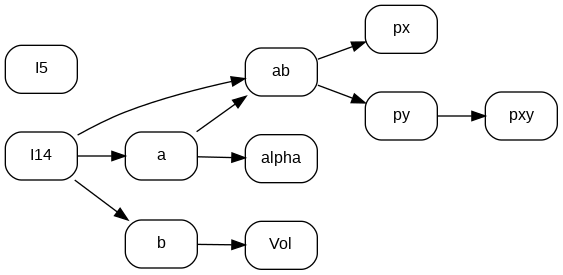

In [ ]:
!pip -q install graphviz pydot
!apt-get -qq install graphviz

import numpy as np
import networkx as nx
from networkx.drawing.nx_pydot import to_pydot
from IPython.display import Image, display

# A: adjacency matrix where A[parent, child] = 1
# names: list of node names in the same order as A
# Example:
# names = ["I14","I5","a","b","ab","alpha","Vol","px","py","pxy"]

def plot_dag_from_adjacency(A, names, out_png="pi_scm_dag.png"):
    G = nx.DiGraph()
    for n in names:
        G.add_node(n)

    d = len(names)
    for i in range(d):
        for j in range(d):
            if A[i, j] == 1:
                G.add_edge(names[i], names[j])

    P = to_pydot(G)
    P.set_rankdir("LR")          # Left-to-right layout
    P.set_splines("true")
    P.set_nodesep("0.4")
    P.set_ranksep("0.5")

    # Pretty nodes
    for node in P.get_nodes():
        node.set_shape("box")
        node.set_style("rounded")
        node.set_fontname("Helvetica")
        node.set_fontsize("12")

    P.write_png(out_png)
    display(Image(out_png))

plot_dag_from_adjacency(A, names)
